In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity

ratings_url = "https://raw.githubusercontent.com/lher96/DATA612/refs/heads/main/ratings.csv"

ratings = pd.read_csv(ratings_url)

ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


## Abstract

This project compares different collaborative filtering approaches using a MovieLens ratings dataset. The dataset contains user and movie ratings where each row represents a rating given by a user that I will split 0/20 for our test and training data. The goal was to evaluate how well different recommender system methods could predict movie ratings with different methods of cosine similarity matrices for User User and Item Item models. I implemented User User Collaborative Filtering and Item Item Collaborative Filtering using both raw cosine similarity and mean centered cosine similarity. Each model was tested across multiple neighborhood sizes from 5, to 50 neighbors. Model performance was evaluated using RMSE and MAE on both training and test data. Overall, Item Item Collaborative Filtering using raw cosine similarity with a neighborhood size of 20 produced the best test performance suggesting that Item Item similarity was more reliable than UsercUser similarity for this dataset.


In [9]:
#Split training and test data 80/20 
train, test = train_test_split(
    ratings,
    test_size=0.2,
    random_state=50
)


print(train.shape)
print(test.shape)

#create user item matrix or utility matrix with movies as column
#this will have substantial missing values due to users which could prove beneficial for our item-item model but sparse for user-user

user_item_matrix = train.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
)

user_item_matrix.head()




(80668, 4)
(20168, 4)


movieId,1,2,3,4,5,6,7,8,9,10,...,191005,193565,193567,193571,193573,193579,193581,193583,193585,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
#some simple statistics about our dataset and checking for missing values
print("Number of ratings:", len(ratings))
print("Number of users:", ratings["userId"].nunique())
print("Number of movies:", ratings["movieId"].nunique())
print("Missing values:")
print(ratings.isna().sum())

Number of ratings: 100836
Number of users: 610
Number of movies: 9724
Missing values:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


In [16]:
#Cosine similarity of users

matrix_filled = user_item_matrix.fillna(0)

user_similarity = cosine_similarity(matrix_filled)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)

user_similarity_df.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
userId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.016390,0.050302,0.181896,0.079666,0.108300,0.101038,0.112251,0.030082,0.011933,...,0.044454,0.132522,0.170214,0.070146,0.118217,0.129239,0.195367,0.235305,0.088545,0.117108
2,0.016390,1.000000,0.000000,0.004385,0.000000,0.016816,0.031808,0.000000,0.000000,0.077316,...,0.190125,0.000000,0.014183,0.000000,0.000000,0.022786,0.000000,0.035596,0.000000,0.081468
3,0.050302,0.000000,1.000000,0.002578,0.000000,0.001335,0.000000,0.005749,0.000000,0.000000,...,0.005538,0.003636,0.027474,0.000000,0.000000,0.008422,0.002699,0.012759,0.000000,0.036934
4,0.181896,0.004385,0.002578,1.000000,0.110210,0.065764,0.074359,0.038262,0.000000,0.025487,...,0.032619,0.093981,0.252200,0.047927,0.074716,0.154116,0.113225,0.122024,0.033691,0.097104
5,0.079666,0.000000,0.000000,0.110210,1.000000,0.224769,0.094678,0.274186,0.000000,0.037784,...,0.017391,0.300579,0.062015,0.220212,0.136636,0.071130,0.054358,0.096062,0.204266,0.040824


In [19]:
#cosine similarity of items or movies in our case

item_similarity = cosine_similarity(matrix_filled.T)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=user_item_matrix.columns,
    columns=user_item_matrix.columns
)

item_similarity_df.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,191005,193565,193567,193571,193573,193579,193581,193583,193585,193609
movieId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.350310,0.240483,0.039560,0.269680,0.253116,0.256238,0.043696,0.165360,0.343365,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.350310,1.000000,0.239625,0.063982,0.214368,0.179867,0.195468,0.112792,0.038846,0.285142,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.240483,0.239625,1.000000,0.096470,0.356790,0.251338,0.413784,0.244193,0.302828,0.195655,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.039560,0.063982,0.096470,1.000000,0.199971,0.102293,0.300234,0.263371,0.000000,0.069522,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.269680,0.214368,0.356790,0.199971,1.000000,0.276970,0.485840,0.136807,0.357785,0.170793,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Cosine Similarity

In doing this portion I had a lot of questions about how to handle the Na's since they were abundant and across so many movies this similarity could be obscured by using 0 instead of some other metric of performance. For this reason I wanted to attempt this using a similarity system and the one I decided to use was based on mean rating. This is more of a question of "how often do users rate a movie above their mean rating". I thought about this specifically to apply a personality to the math. Whether it's movies, stocks, or even tech, people tend to have a certain level of liberalness to their ratings of anything. I may be more harsh on a stock than any type of movie because it it matters to me very differently than the movie I watch for leisure. This would likely be an unshared sentiment by a movie critic who takes their ratings very seriously and doesn't want it to be sullied. For this reason I wanted to apply an alternative standard which I chose to be mean centered similarity. 

In [22]:
# Mean centered
user_centered_matrix = user_item_matrix.sub(user_item_matrix.mean(axis=1),axis=0)

# now fill missing values with 0 
user_centered_filled = user_centered_matrix.fillna(0)

#recalculate cosine similarity and similarity matrix
user_centered_similarity = cosine_similarity(user_centered_filled)


user_centered_similarity_df = pd.DataFrame(
    user_centered_similarity,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)

user_centered_similarity_df.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
userId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,-0.000286,0.011858,0.010371,-0.015493,-0.041477,-0.000797,0.038075,0.001532,-0.013040,...,0.019995,-0.026288,-0.012872,-0.051598,0.006462,0.011242,0.020801,0.053512,-0.028170,0.005679
2,-0.000286,1.000000,0.000000,-0.017721,0.000000,-0.000545,-0.009964,0.000000,0.000000,0.005234,...,-0.030351,0.000000,-0.002085,0.000000,0.000000,0.004449,0.000000,-0.004532,0.000000,0.011670
3,0.011858,0.000000,1.000000,-0.014516,0.000000,0.006051,0.000000,-0.041125,0.000000,0.000000,...,-0.004194,-0.030123,0.010121,0.000000,0.000000,-0.045122,-0.018165,-0.017361,0.000000,0.021775
4,0.010371,-0.017721,-0.014516,1.000000,-0.006087,0.000615,0.031853,-0.009155,0.000000,0.036173,...,-0.027399,0.037533,0.011175,0.014173,0.025791,0.032026,0.004191,-0.017025,0.021005,0.003865
5,-0.015493,0.000000,0.000000,-0.006087,1.000000,-0.003693,0.000675,-0.052329,0.000000,-0.038062,...,-0.006736,-0.033630,0.017217,0.014452,-0.031372,0.007403,0.032924,0.021976,0.099070,0.002122


In [23]:
# Mean centered by item
item_centered_matrix = user_item_matrix.sub(user_item_matrix.mean(axis=0),axis=1)

#again fill missing values 
item_centered_filled = item_centered_matrix.fillna(0)

#recalculate cosine similarity between items/movies and transpose because movies are currently columns but need to be rows, then use columns for item-item
item_centered_similarity = cosine_similarity(item_centered_filled.T)

#item item similarity DataFrame
item_centered_similarity_df = pd.DataFrame(
    item_centered_similarity,
    index=user_item_matrix.columns,
    columns=user_item_matrix.columns
)

item_centered_similarity_df.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,191005,193565,193567,193571,193573,193579,193581,193583,193585,193609
movieId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.047058,0.093446,0.035589,0.038494,0.037039,0.065700,0.0,0.072291,-0.002872,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.047058,1.000000,0.179139,-0.039340,0.080716,0.090307,0.033757,0.0,0.049276,0.006520,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.093446,0.179139,1.000000,0.075798,0.266336,0.014164,0.240407,0.0,0.203818,0.001685,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.035589,-0.039340,0.075798,1.000000,0.132330,0.005926,0.023581,0.0,0.000000,0.103602,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.038494,0.080716,0.266336,0.132330,1.000000,0.117009,0.246412,0.0,0.062649,0.060177,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
# Baseline values from the training data only

global_mean = train["rating"].mean()

user_means = train.groupby("userId")["rating"].mean()
item_means = train.groupby("movieId")["rating"].mean()

print("Global mean rating:", global_mean)


Global mean rating: 3.5015681558982497


In [25]:
#create function to run user user prediction

def predict_user_user(user_id, movie_id, similarity_df, k=20):
    # If user is not in the training matrix, use the global average
    if user_id not in user_item_matrix.index:
        return global_mean
    
    #If movie is not in the training matrix we are going to use the user's average rating
    if movie_id not in user_item_matrix.columns:
        return user_means.get(user_id, global_mean)
    
    #Finding users who rated this movie
    movie_ratings = user_item_matrix[movie_id].dropna()
    
    #Removing the target user if present
    movie_ratings = movie_ratings.drop(index=user_id, errors="ignore")
    
    if movie_ratings.empty:
        return user_means.get(user_id, global_mean)
    
    #Similarities between the target user and users who rated the movie
    similarities = similarity_df.loc[user_id, movie_ratings.index]

    similarities = similarities[similarities > 0]
    
    if similarities.empty:
        return user_means.get(user_id, global_mean)
    
    #Select top k most similar users
    top_k_users = similarities.sort_values(ascending=False).head(k)
    
    #Ratings from those similar users
    top_k_ratings = movie_ratings.loc[top_k_users.index]
    
    #Mean centered neighbor ratings by each neighbor's average rating
    neighbor_means = user_means.loc[top_k_users.index]
    rating_diffs = top_k_ratings - neighbor_means
    
    #Weighted prediction
    prediction = user_means.loc[user_id] + (
        np.dot(top_k_users, rating_diffs) / top_k_users.sum()
    )
    
    #Keep prediction within MovieLens' rating scale
    return min(max(prediction, 0.5), 5.0)

In [26]:
#create function to run item item prediction

def predict_item_item(user_id, movie_id, similarity_df, k=20):
    #If user is not in the training matrix we will use the movie average
    if user_id not in user_item_matrix.index:
        return item_means.get(movie_id, global_mean)
    
    #If movie is not in the training matrix we will use the user's average
    if movie_id not in user_item_matrix.columns:
        return user_means.get(user_id, global_mean)
    
    #Find movies this user has rated
    user_ratings = user_item_matrix.loc[user_id].dropna()
    
    #Remove the target movie if present
    user_ratings = user_ratings.drop(index=movie_id, errors="ignore")
    
    if user_ratings.empty:
        return user_means.get(user_id, global_mean)
    
    #Similarities between the target movie and movies the user rated
    similarities = similarity_df.loc[movie_id, user_ratings.index]
    
    #Keep only positive similarities
    similarities = similarities[similarities > 0]
    
    if similarities.empty:
        return user_means.get(user_id, global_mean)
    
    #Select top k most similar movies
    top_k_items = similarities.sort_values(ascending=False).head(k)
    
    #User's ratings for those similar movies
    top_k_ratings = user_ratings.loc[top_k_items.index]
    
    #Mean centered using item averages
    neighbor_item_means = item_means.loc[top_k_items.index]
    rating_diffs = top_k_ratings - neighbor_item_means
    
    #Weighted predictions
    prediction = item_means.loc[movie_id] + (
        np.dot(top_k_items, rating_diffs) / top_k_items.sum()
    )
    
    #Keep predictions within MovieLens' rating scale
    return min(max(prediction, 0.5), 5.0)

In [27]:
#Function to evaluate predictions and use across different k values

def evaluate_model(data, model_type, similarity_df, k=20):
    predictions = []
    
    for row in data.itertuples():
        user_id = row.userId
        movie_id = row.movieId
        
        if model_type == "user_user":
            pred = predict_user_user(
                user_id=user_id,
                movie_id=movie_id,
                similarity_df=similarity_df,
                k=k
            )
        elif model_type == "item_item":
            pred = predict_item_item(
                user_id=user_id,
                movie_id=movie_id,
                similarity_df=similarity_df,
                k=k
            )
        else:
            raise ValueError("model_type must be 'user_user' or 'item_item'")
        
        predictions.append(pred)
    
    actual = data["rating"].values
    
    rmse = root_mean_squared_error(actual, predictions)
    mae = mean_absolute_error(actual, predictions)
    
    return rmse, mae

In [32]:

train_eval = train
test_eval = test

results = []

k_values = [5, 10, 20, 50]

for k in k_values:
    
    # User-User Raw Cosine
    train_rmse, train_mae = evaluate_model(
        train_eval,
        model_type="user_user",
        similarity_df=user_similarity_df,
        k=k
    )
    
    test_rmse, test_mae = evaluate_model(
        test_eval,
        model_type="user_user",
        similarity_df=user_similarity_df,
        k=k
    )
    
    results.append({
        "model": "User-User CF",
        "similarity": "Raw Cosine",
        "k": k,
        "train_RMSE": train_rmse,
        "train_MAE": train_mae,
        "test_RMSE": test_rmse,
        "test_MAE": test_mae
    })
    
    # User-User Mean-Centered Cosine
    train_rmse, train_mae = evaluate_model(
        train_eval,
        model_type="user_user",
        similarity_df=user_centered_similarity_df,
        k=k
    )
    
    test_rmse, test_mae = evaluate_model(
        test_eval,
        model_type="user_user",
        similarity_df=user_centered_similarity_df,
        k=k
    )
    
    results.append({
        "model": "User-User CF",
        "similarity": "Mean-Centered Cosine",
        "k": k,
        "train_RMSE": train_rmse,
        "train_MAE": train_mae,
        "test_RMSE": test_rmse,
        "test_MAE": test_mae
    })
    
    # Item-Item Raw Cosine
    train_rmse, train_mae = evaluate_model(
        train_eval,
        model_type="item_item",
        similarity_df=item_similarity_df,
        k=k
    )
    
    test_rmse, test_mae = evaluate_model(
        test_eval,
        model_type="item_item",
        similarity_df=item_similarity_df,
        k=k
    )
    
    results.append({
        "model": "Item-Item CF",
        "similarity": "Raw Cosine",
        "k": k,
        "train_RMSE": train_rmse,
        "train_MAE": train_mae,
        "test_RMSE": test_rmse,
        "test_MAE": test_mae
    })
    
    # Item-Item Mean-Centered Cosine
    train_rmse, train_mae = evaluate_model(
        train_eval,
        model_type="item_item",
        similarity_df=item_centered_similarity_df,
        k=k
    )
    
    test_rmse, test_mae = evaluate_model(
        test_eval,
        model_type="item_item",
        similarity_df=item_centered_similarity_df,
        k=k
    )
    
    results.append({
        "model": "Item-Item CF",
        "similarity": "Mean-Centered Cosine",
        "k": k,
        "train_RMSE": train_rmse,
        "train_MAE": train_mae,
        "test_RMSE": test_rmse,
        "test_MAE": test_mae
    })

results_df = pd.DataFrame(results)
results_df

,model,similarity,k,train_RMSE,train_MAE,test_RMSE,test_MAE
0,User-User CF,Raw Cosine,5,0.902334,0.688311,0.917619,0.700182
1,User-User CF,Mean-Centered Cosine,5,0.801621,0.610024,0.906801,0.690986
2,Item-Item CF,Raw Cosine,5,0.760829,0.564588,0.886558,0.674286
3,Item-Item CF,Mean-Centered Cosine,5,0.567871,0.428576,0.900960,0.684657
4,User-User CF,Raw Cosine,10,0.882982,0.671390,0.895571,0.681255
5,User-User CF,Mean-Centered Cosine,10,0.789878,0.598569,0.888587,0.674581
6,Item-Item CF,Raw Cosine,10,0.744326,0.554517,0.864855,0.658421
7,Item-Item CF,Mean-Centered Cosine,10,0.544745,0.409552,0.877500,0.667002
8,User-User CF,Raw Cosine,20,0.877178,0.666600,0.890291,0.676783
9,User-User CF,Mean-Centered Cosine,20,0.791658,0.599142,0.883902,0.669705


## Interpretation of Model Functions

 For User User Collaborative Filtering, the function first finds users who rated the target movie and then identifies the most similar users to the target user. The prediction is calculated as a weighted average of those similar users’ ratings and adjusted by each user’s average rating. This helps account for the fact that some users are naturally more strict or more generous with ratings. For Item Item Collaborative Filtering the function instead looks at movies the target user has already rated and compares those movies to the target movie. The prediction was based on the user’s ratings of the most similar movies. In both models, fallback averages such as the global mean, user mean, or item mean are used when there is not enough information to make a collaborative filtering prediction. This was to prevent the model from failing when a user or movie is missing from the training matrix and this problem had to be addressed. Data imputation methods are always a valuable question of comparison and here this was how I chose to deal with these values.


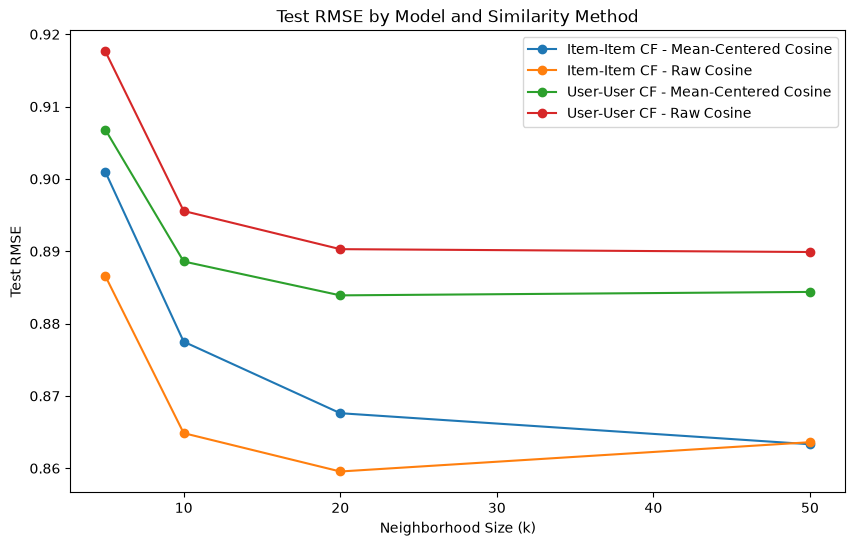

In [33]:
#graph of test rmse

plt.figure(figsize=(10, 6))

for label, group in results_df.groupby(["model", "similarity"]):
    model_name, similarity_name = label
    
    plt.plot(
        group["k"],
        group["test_RMSE"],
        marker="o",
        label=f"{model_name} - {similarity_name}"
    )

plt.xlabel("Neighborhood Size (k)")
plt.ylabel("Test RMSE")
plt.title("Test RMSE by Model and Similarity Method")
plt.legend()
plt.show()

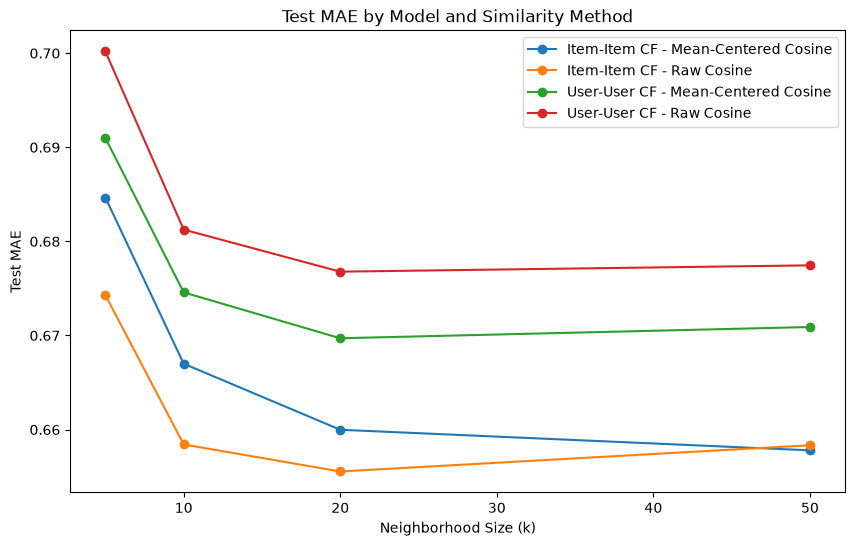

In [34]:
#graph of test mae

plt.figure(figsize=(10, 6))

for label, group in results_df.groupby(["model", "similarity"]):
    model_name, similarity_name = label
    
    plt.plot(
        group["k"],
        group["test_MAE"],
        marker="o",
        label=f"{model_name} - {similarity_name}"
    )

plt.xlabel("Neighborhood Size (k)")
plt.ylabel("Test MAE")
plt.title("Test MAE by Model and Similarity Method")
plt.legend()
plt.show()

In [35]:
results_df.sort_values("test_RMSE").head()
results_df.sort_values("test_MAE").head()

,model,similarity,k,train_RMSE,train_MAE,test_RMSE,test_MAE
10,Item-Item CF,Raw Cosine,20,0.742591,0.554588,0.859551,0.655545
15,Item-Item CF,Mean-Centered Cosine,50,0.547881,0.407605,0.863320,0.657795
14,Item-Item CF,Raw Cosine,50,0.748854,0.561253,0.863602,0.658334
6,Item-Item CF,Raw Cosine,10,0.744326,0.554517,0.864855,0.658421
11,Item-Item CF,Mean-Centered Cosine,20,0.539399,0.403436,0.867611,0.659982


## Interpretation of Results

The results show that Item Item Collaborative Filtering generally performed better than User User Collaborative Filtering. Across the different neighborhood sizes the Item Item models produced lower test RMSE and MAE values which means they made more accurate predictions on unseen ratings. The best performing model was Item Item Collaborative Filtering with raw cosine similarity and a neighborhood size of 20 to be specific which shows that simply increasing k likely wouldn't make much improvement but the raw cosine was still performing better. This model achieved a test RMSE of 0.8596 and a test MAE of 0.6555. Increasing the neighborhood size from 5 to 20 improved performance for most models also while increasing it to 50 did not provide much additional improvement. This suggests that using more neighbors can help up to a point is valuable so breaking those values even smaller could be another question to be tested. Mean centered cosine similarity improved the UserUser model compared to raw cosine which supported my original theory that this would better represent users. Despite this it did not outperform raw cosine for the Item Item model. Based on these results the Item Item Raw Cosine model with k=20 was the best because it had the strongest test performance.
